In [97]:
# Idempotent, Colab-safe: import SIP, installing the course-pinned version if missing.
SIP_PIN = "v0.4.0"  # course-pinned SIP version
SIP_GIT = "git+https://github.com/vvvasconcelos/SystemsInsightPipeline.git"
try:
    import sip_systemsinsightpipeline as sip
except ImportError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", f"{SIP_GIT}@{SIP_PIN}"],
        check=True,
    )
    import sip_systemsinsightpipeline as sip
print("SIP", sip.__version__, "ready")

# If SIP was ALREADY importable, the install above never ran - so check the version
# we actually got. A stale SIP silently produces different numbers from the ones
# this notebook expects.
if sip.__version__ != SIP_PIN.lstrip("v"):
    print("\n!! WARNING: this notebook expects SIP", SIP_PIN,
          "but version", sip.__version__, "is installed.")
    print("   The expected values printed in this notebook may not reproduce.")
    print("   Fix:  %pip install --force-reinstall --no-deps " + SIP_GIT + "@" + SIP_PIN)
    print("   ...then restart the kernel and re-run.")

SIP 0.4.0 ready


In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter

for _b in [Path.cwd(), *Path.cwd().parents]:
    _c = _b / "templates" / "polder.mplstyle"
    if _c.exists():
        plt.style.use(str(_c)); break

TEAL, DARK_TEAL, CORAL, SLATE = "#00A39B", "#006661", "#E8633A", "#5F6B7A"
print("Setup OK.")

Setup OK.


ELEMENTS
                                                                      Label      Type  Tags                                     Description
                                 % households with PV/EV/heat pump/battery     Stock     0                                             NaN
               congestion (forecasted power use / projected grid capacity)     Stock     0                                             VOI
                    €/(time unit) subsidy for electrification (households) Auxiliary     0                                             NaN
                            position of energy transition political agenda     Stock     1                                             NaN
                                 spare capacity in the grid (GW/time unit) Auxiliary     0                                             NaN
                                           €/(time unit) public investment Auxiliary     0                                             NaN
willingness to ad

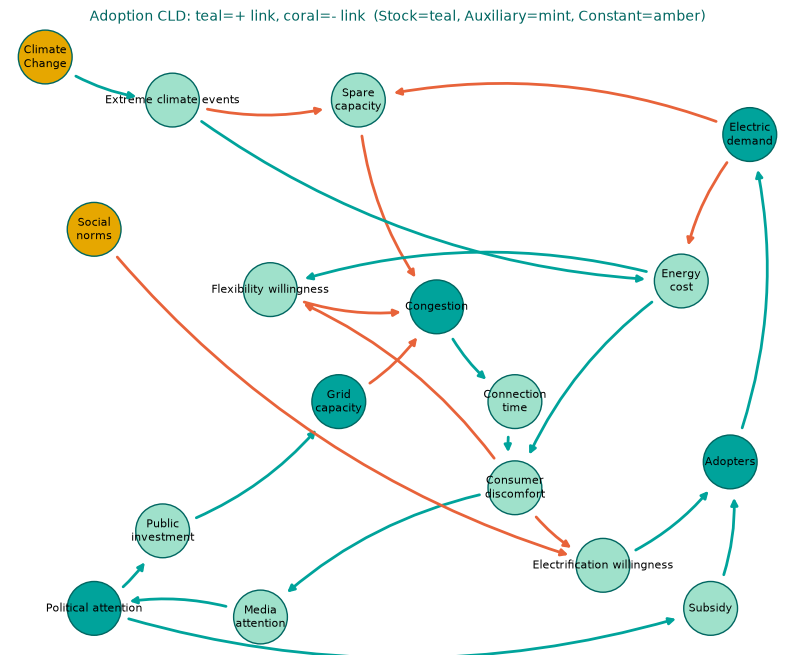

In [99]:
# Draw the CLD straight from the Excel, so you can read the structure SIP will use.
import networkx as nx
elem = pd.read_excel("kumu-nicky-csp26-csp-1a.xlsx", sheet_name="Elements")
conn = pd.read_excel("kumu-nicky-csp26-csp-1a.xlsx", sheet_name="Connections")
print("ELEMENTS\n", elem.to_string(index=False))
print("\nCONNECTIONS\n", conn[["From", "To", "Type"]].to_string(index=False))

short = {
    "% households with PV/EV/heat pump/battery": "Adopters",
    "€/(time unit) subsidy for electrification (households)": "Subsidy",
    "household energy cost": "Energy\ncost",
    "prioritization of energy transition in laws and regulations": "Policy\npriority",
    "spare capacity in the grid (GW/time unit)": "Spare\ncapacity",
    "willingness to adopt househehold electrification technologies (scale 0-10)": "Electrification willingness",
    "% energy demand that is electric": "Electric\ndemand",
    "willingness to flexibile use (scale 1-10)": "Flexibility willingness",
    "social norms": "Social\nnorms",
    "climate change": "Climate\nChange",
    "incidence of extreme climate events (# per time unit)": "Extreme climate events",
    "energy poverty (cost)": "Energy\npoverty",
    "grid capacity GW": "Grid\ncapacity",
    "media attention index": "Media\nattention",
    "new connection lead time (days in queue)": "Connection\ntime",
    "perceived injustice / consumers discomfort (scale 0-10)": "Consumer\ndiscomfort",
    "€/(time unit) public investment": "Public\ninvestment",
    "position of energy transition political agenda": "Political attention",
    "grid reinforcement (GW/time unit)": "Grid\nreinforcement",
    "congestion (forecasted power use / projected grid capacity)": "Congestion"
}

pos = {
    # --- Climate drivers ---
    "Climate\nChange": (-4.0, 3.2),
    "Extreme climate events": (-2.7, 2.7),

    # --- Grid / physical system ---
    "Spare\ncapacity": (-0.8, 2.7),
    "Grid\ncapacity": (-1, -0.8),
    "Grid\nreinforcement": (-2.2, -0.8),
    "Congestion": (0.0, 0.3),
    "Electric\ndemand": (3.2, 2.3),
    "Energy\ncost": (2.5, 0.6),
    "Energy\npoverty": (1.7, 1.2),
    "Connection\ntime": (0.8, -0.8),

    # --- Social / behavioural ---
    "Social\nnorms": (-3.5, 1.2),
    "Flexibility willingness": (-1.7, 0.5),
    "Consumer\ndiscomfort": (0.8, -1.8),
    "Electrification willingness": (1.7, -2.7),

    # --- Policy / political response ---
    "Policy\npriority": (-1.0, -2.0),
    "Public\ninvestment": (-2.8, -2.3),
    "Political attention": (-3.5, -3.2),
    "Media\nattention": (-1.8, -3.3),
    "Subsidy": (2.8, -3.2),

    # --- Adoption ---
    "Adopters": (3.0, -1.5),

}
G = nx.DiGraph()
for _, row in conn.iterrows():
    G.add_edge(short[row["From"]], short[row["To"]], sign=row["Type"])
fig, ax = plt.subplots(figsize=(10, 8))
kinds = {short[r.Label]: r.Type for r in elem.itertuples(index=False)}
ncol = {"Stock": TEAL, "Auxiliary": "#9FE1CB", "Constant": "#E6A700"}
nx.draw_networkx_nodes(G, pos, node_size=1500,
                       node_color=[ncol[kinds[n]] for n in G.nodes], edgecolors=DARK_TEAL, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
for u, v, d in G.edges(data=True):
    col = TEAL if d["sign"] == "+" else CORAL
    ax.annotate("", xy=pos[v], xytext=pos[u],
                arrowprops=dict(arrowstyle="-|>", color=col, lw=2,
                                connectionstyle="arc3,rad=0.16", shrinkA=26, shrinkB=26))
ax.set_title("Adoption CLD: teal=+ link, coral=- link  (Stock=teal, Auxiliary=mint, Constant=amber)",
             color=DARK_TEAL, fontsize=10)
ax.axis("off"); plt.show()

In [100]:
from sip_systemsinsightpipeline import Extract, SDM

s = Extract("kumu-nicky-csp26-csp-1a.xlsx").extract_settings()
print("Variable of interest :", s.variable_of_interest)
print("Interventions (levers):", s.intervention_variables)
print("Stocks    :", s.stocks)
print("Auxiliaries:", s.auxiliaries)
print("Constants :", s.constants)

Variable of interest: congestion (forecasted power use / projected grid capacity)
with 4 intervention variables

2 feedback loops of maximum length 5
All loops have at least one stock
No interaction terms specified so will solve linear SDM.
Variable of interest : ['congestion (forecasted power use / projected grid capacity)']
Interventions (levers): ['position of energy transition political agenda', 'willingness to adopt househehold electrification technologies (scale 0-10)', 'willingness to flexibile use (scale 1-10)', 'incidence of extreme climate events (# per time unit)']
Stocks    : ['% households with PV/EV/heat pump/battery', 'congestion (forecasted power use / projected grid capacity)', 'position of energy transition political agenda', '% energy demand that is electric', 'grid capacity GW']
Auxiliaries: ['€/(time unit) subsidy for electrification (households)', 'spare capacity in the grid (GW/time unit)', '€/(time unit) public investment', 'willingness to adopt househehold elec

In [101]:
for p in [0.1, 0.2, 0.3]:
    s.N = 1000
    s.seed = 0
    s.t_end = 20
    s.time_unit = "trimester"
    s.parameter_value_aux = p
    s.parameter_value_stocks = p #to check for robustness of the results

    sdm = SDM(s)
    df_sol, params = sdm.run_simulations()
    effects = sdm.get_intervention_effects()

    voi = s.variable_of_interest[0]
    lev = effects[voi]

    med = {
        k: float(np.median(v))
        for k, v in lev.items()
    }

    ranking = sorted(med, key=med.get, reverse=True)

    print(f"\nParameter value = {p}")
    for i, k in enumerate(ranking, 1):
        print(f"{i:2}. {k}: {med[k]:+.3f}")

Running Simulations:   0%|          | 0/1000 [00:00<?, ?it/s]

Running Simulations: 100%|██████████| 1000/1000 [00:23<00:00, 41.72it/s]



Parameter value = 0.1
 1. incidence of extreme climate events (# per time unit): +0.033
 2. willingness to adopt househehold electrification technologies (scale 0-10): +0.004
 3. position of energy transition political agenda: -0.012
 4. willingness to flexibile use (scale 1-10): -0.991


Running Simulations: 100%|██████████| 1000/1000 [00:21<00:00, 46.31it/s]



Parameter value = 0.2
 1. incidence of extreme climate events (# per time unit): +0.126
 2. willingness to adopt househehold electrification technologies (scale 0-10): +0.067
 3. position of energy transition political agenda: -0.089
 4. willingness to flexibile use (scale 1-10): -1.982


...

Running Simulations:  93%|█████████▎| 933/1000 [00:32<00:01, 49.48it/s]

Running Simulations:  95%|█████████▌| 951/1000 [00:33<00:01, 26.83it/s]

Running Simulations:  99%|█████████▊| 986/1000 [00:33<00:00, 48.34it/s]

Running Simulations: 100%|██████████| 1000/1000 [00:34<00:00, 29.23it/s]


Parameter value = 0.3
 1. willingness to adopt househehold electrification technologies (scale 0-10): +0.364
 2. incidence of extreme climate events (# per time unit): +0.267
 3. position of energy transition political agenda: -0.250
 4. willingness to flexibile use (scale 1-10): -2.980


In [102]:
# Tell SIP how to explore the unknown link strengths, then simulate.
s.seed = 0
s.N = 1000 #tested at 200,500,1000,2000 (with 1000 found to be the best in accuracy/time) 
s.t_end = 20
s.time_unit = 'trimester'
s.parameter_value_aux = 0.2
s.parameter_value_stocks = 0.2


sdm = SDM(s)
df_sol, params = sdm.run_simulations()
effects = sdm.get_intervention_effects()
voi = s.variable_of_interest[0]
lev = effects[voi]

Running Simulations: 100%|██████████| 1000/1000 [00:30<00:00, 32.50it/s]


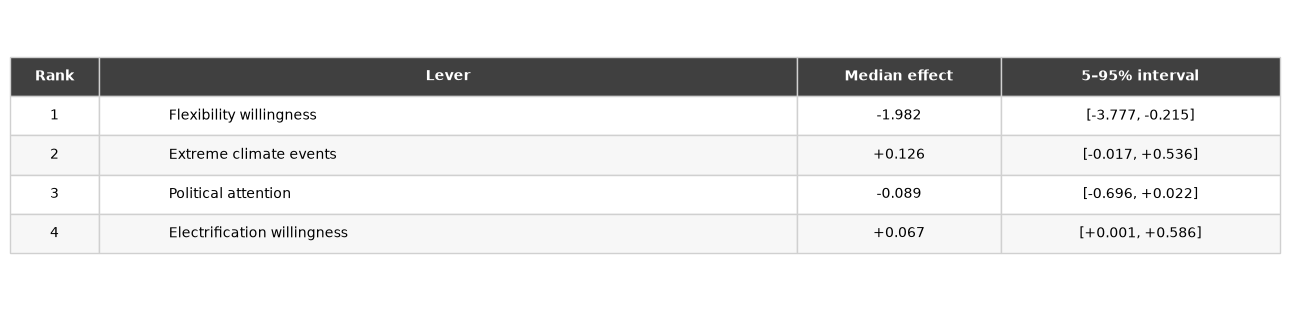

In [103]:
# Collapse each lever's distribution
med = {k: float(np.median(v)) for k, v in lev.items()}
lo  = {k: float(np.percentile(v, 5)) for k, v in lev.items()}
hi  = {k: float(np.percentile(v, 95)) for k, v in lev.items()}

# Sort by absolute median effect, strongest first
ranking = sorted(med, key=lambda k: abs(med[k]), reverse=True)

df = pd.DataFrame({
    "Rank": range(1, len(ranking) + 1),
    "Lever": [short.get(k, k) for k in ranking],
    "Median effect": [f"{med[k]:+.3f}" for k in ranking],
    "5–95% interval": [
        f"[{lo[k]:+.3f}, {hi[k]:+.3f}]" for k in ranking
    ]
})

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.07, 0.55, 0.16, 0.22]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header and rows
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D0D0")

    if row == 0:
        cell.set_facecolor("#404040")
        cell.set_text_props(weight="bold", color="white", ha="center")
        
    else:
        cell.set_facecolor("#F7F7F7" if row % 2 == 0 else "white")

# Center numerical columns
for row in range(1, len(df) + 1):
    for col in [0, 2, 3]:
        table[(row, col)].get_text().set_ha("center")

plt.tight_layout()

# Export as high-resolution PNG
plt.savefig(
    "lever_effects_ranking.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

/var/folders/jm/smnvdnts7bz6zds230x8x84m0000gn/T/ipykernel_40935/2852396098.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(


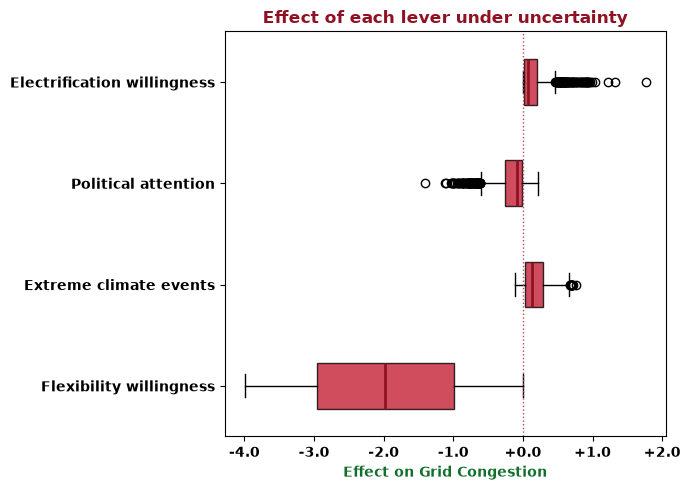

In [104]:
# Boxplot of each lever's effect distribution
names = list(lev)
plot_names = [short.get(n, n) for n in names]

fig, ax = plt.subplots(figsize=(7, 5))

bp = ax.boxplot(
    [lev[n] for n in names],
    vert=False,
    tick_labels=plot_names,
    patch_artist=True,
    medianprops=dict(color="#8F1122", lw=2)
)


for box in bp['boxes']:
    box.set(facecolor="#C52036", alpha=.80)

ax.axvline(0, color="#BD4858", ls=':', lw=1)
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:+.1f}")
)
ax.set_xlabel(f"Effect on Grid Congestion", color="#126F2C", fontweight="bold")
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

ax.set_title("Effect of each lever under uncertainty",color="#8F1122", fontweight="bold")

plt.tight_layout()
plt.show()